# SCRIPT 22 - RF
# Model: RF_B2B3 → X = [B2, B3], RF_B2 → X = [B2], RF_B3 → X = [B3]
# Y: Kelembaban tanah

## Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import Library

In [2]:
import os
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 1. Konfigurasi path data dan hasil

In [3]:
PATH_LAPANG  = '/content/drive/MyDrive/Skripsi/Data Lapang/Hasil_Lapangan.csv'
PATH_CITRA_A = '/content/drive/MyDrive/Skripsi/Data Citra/kelompokA_10m_Mei2026_modified.csv'

OUT_DIR = '/content/drive/MyDrive/Skripsi/Hasil Pemodelan Baru/RF_B2B3/'
os.makedirs(OUT_DIR, exist_ok=True)

## 2. Load dan merge data CSV

In [4]:
df_lapang = pd.read_csv(PATH_LAPANG)
df_A      = pd.read_csv(PATH_CITRA_A)

df_merged = pd.merge(
    df_lapang[['Titik_Pengamatan', 'Kelembaban (%)']],
    df_A[['Titik_Pengamatan', 'B2', 'B3']],
    on='Titik_Pengamatan'
).dropna()

print("=" * 55)
print("DATA SETELAH MERGE")
print("=" * 55)
print(f"Jumlah sampel : {df_merged.shape[0]}")
print(f"Band tersedia : B2, B3")

DATA SETELAH MERGE
Jumlah sampel : 42
Band tersedia : B2, B3


## 3. Define feature dan target

In [5]:
Y_raw  = df_merged['Kelembaban (%)'].values

X_B2B3 = df_merged[['B2', 'B3']].values
X_B2   = df_merged[['B2']].values
X_B3   = df_merged[['B3']].values

## 4. Hyperparameter grid

In [6]:
param_grid = {
    'n_estimators'      : [100, 200, 300],
    'max_depth'         : [3, 4, 5],
    'min_samples_split' : [2, 5],
    'min_samples_leaf'  : [2, 3]
}

## 5. Fold set-up

In [7]:
OUTER_KF = KFold(n_splits=10, shuffle=True, random_state=42)
INNER_KF = KFold(n_splits=5,  shuffle=True, random_state=42)

## 6. Fungsi training RF (Nested CV)

In [8]:
def train_rf(X, Y, label, bands, out_path, df_merged):
    print(f"\n{'=' * 55}")
    print(f"MODEL : {label}")
    print(f"Band  : {bands}")
    print(f"{'=' * 55}")

    Y_pred_all       = np.zeros(len(Y))
    best_params_list = []

    print("Menjalankan Nested CV (outer=10, inner=5)...")
    for fold_i, (train_idx, test_idx) in enumerate(OUTER_KF.split(X)):
        X_train, X_test = X[train_idx], X[test_idx]
        Y_train         = Y[train_idx]

        rf_base     = RandomForestRegressor(random_state=42)
        grid_search = GridSearchCV(
            rf_base, param_grid,
            cv=INNER_KF,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1
        )
        grid_search.fit(X_train, Y_train)
        best_p = grid_search.best_params_
        best_params_list.append(best_p)

        rf_best = RandomForestRegressor(**best_p, random_state=42)
        rf_best.fit(X_train, Y_train)
        Y_pred_all[test_idx] = rf_best.predict(X_test)

    Y_pred_all = np.clip(Y_pred_all, 0, 100)

    # Hyperparameter paling sering terpilih
    params_summary = {}
    for key in param_grid.keys():
        vals = [p[key] for p in best_params_list]
        params_summary[key] = Counter(vals).most_common(1)[0][0]

    print(f"\nHyperparameter paling sering terpilih (dari 10 outer fold):")
    for k, v in params_summary.items():
        print(f"  {k}: {v}")

    # Metrik
    rmse = np.sqrt(mean_squared_error(Y, Y_pred_all))
    mae  = mean_absolute_error(Y, Y_pred_all)
    r2   = r2_score(Y, Y_pred_all)
    rpd  = np.std(Y) / rmse

    print(f"\nMETRIK PERFORMA (Nested CV):")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    print(f"  RPD  : {rpd:.4f}  "
          f"{'(tidak layak <1.5)' if rpd < 1.5 else '(estimasi kasar 1.5-2.0)' if rpd < 2.0 else '(reliable >2.0)'}")

    # Fit ulang seluruh data untuk feature importance
    rf_final = RandomForestRegressor(**params_summary, random_state=42)
    rf_final.fit(X, Y)
    imp_df = pd.DataFrame({
        'Band'      : bands,
        'Importance': rf_final.feature_importances_
    }).sort_values('Importance', ascending=False)

    print(f"\nFEATURE IMPORTANCE:")
    print(imp_df.to_string(index=False))

    # Simpan CSV
    safe = label.replace(' ', '_').replace('(', '').replace(')', '')

    pd.DataFrame({
        'Titik_Pengamatan'   : df_merged['Titik_Pengamatan'].values,
        'Kelembaban_Aktual'  : Y,
        'Kelembaban_Prediksi': Y_pred_all,
        'Residual'           : Y - Y_pred_all
    }).to_csv(out_path + f'prediksi_{safe}.csv', index=False)

    imp_df.to_csv(out_path + f'feature_importance_{safe}.csv', index=False)

    pd.DataFrame([{
        'Model': label,
        'RMSE' : round(rmse, 4), 'MAE': round(mae, 4),
        'R2'   : round(r2,   4), 'RPD': round(rpd, 4),
        **{f'param_{k}': v for k, v in params_summary.items()}
    }]).to_csv(out_path + f'metrik_{safe}.csv', index=False)

    # Visualisasi
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'Random Forest — {label}', fontsize=13, fontweight='bold')

    ax = axes[0]
    ax.scatter(Y, Y_pred_all, alpha=0.7, color='forestgreen',
               edgecolors='white', s=60)
    lo = min(Y.min(), Y_pred_all.min()) - 2
    hi = max(Y.max(), Y_pred_all.max()) + 2
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='1:1 line')
    ax.set_xlabel('Kelembaban Aktual (%)', fontsize=11)
    ax.set_ylabel('Kelembaban Prediksi (%)', fontsize=11)
    ax.set_title(f'Aktual vs Prediksi\nRMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.3f}  RPD={rpd:.3f}')
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1]
    ip = imp_df.sort_values('Importance')
    ax.barh(ip['Band'], ip['Importance'], color='forestgreen', edgecolor='white')
    ax.set_xlabel('Feature Importance', fontsize=11)
    ax.set_title('Peran Tiap Band\n(fit pada seluruh data)')
    ax.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.savefig(out_path + f'grafik_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Output disimpan ke: {out_path}")

    return {'label': label, 'bands': str(bands),
            'rmse': rmse, 'mae': mae, 'r2': r2, 'rpd': rpd}

## 7. Running Model


MODEL : RF_B2B3
Band  : ['B2', 'B3']
Menjalankan Nested CV (outer=10, inner=5)...

Hyperparameter paling sering terpilih (dari 10 outer fold):
  n_estimators: 300
  max_depth: 3
  min_samples_split: 2
  min_samples_leaf: 3

METRIK PERFORMA (Nested CV):
  RMSE : 14.7840
  MAE  : 11.7176
  R²   : 0.0670
  RPD  : 1.0353  (tidak layak <1.5)

FEATURE IMPORTANCE:
Band  Importance
  B2    0.555169
  B3    0.444831


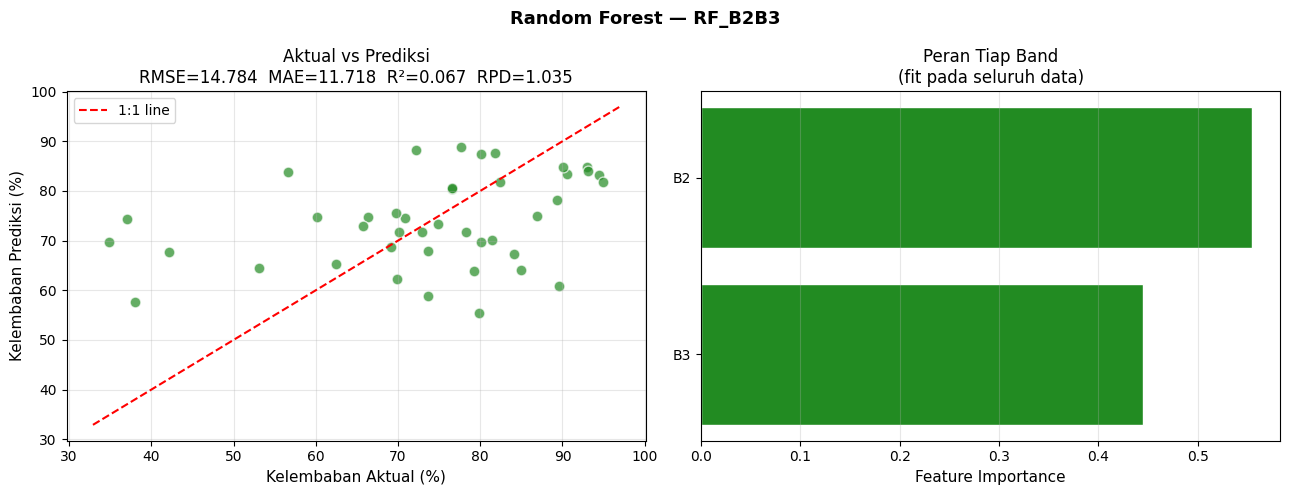

Output disimpan ke: /content/drive/MyDrive/Skripsi/Hasil Pemodelan Baru/RF_B2B3/

MODEL : RF_B2
Band  : ['B2']
Menjalankan Nested CV (outer=10, inner=5)...

Hyperparameter paling sering terpilih (dari 10 outer fold):
  n_estimators: 300
  max_depth: 3
  min_samples_split: 2
  min_samples_leaf: 2

METRIK PERFORMA (Nested CV):
  RMSE : 14.6512
  MAE  : 11.7538
  R²   : 0.0837
  RPD  : 1.0447  (tidak layak <1.5)

FEATURE IMPORTANCE:
Band  Importance
  B2         1.0


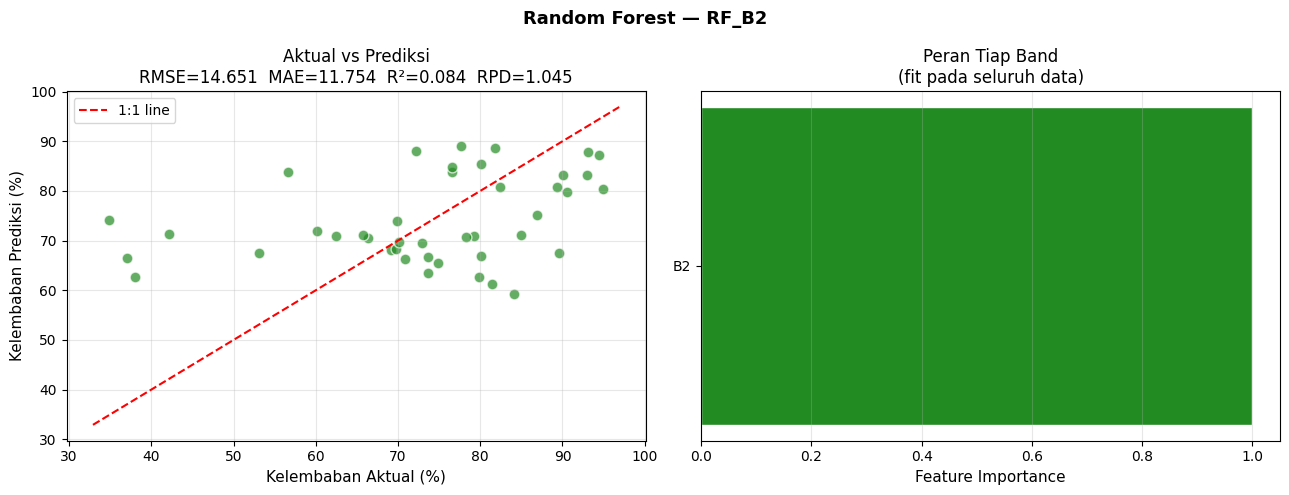

Output disimpan ke: /content/drive/MyDrive/Skripsi/Hasil Pemodelan Baru/RF_B2B3/

MODEL : RF_B3
Band  : ['B3']
Menjalankan Nested CV (outer=10, inner=5)...

Hyperparameter paling sering terpilih (dari 10 outer fold):
  n_estimators: 300
  max_depth: 3
  min_samples_split: 2
  min_samples_leaf: 3

METRIK PERFORMA (Nested CV):
  RMSE : 14.7828
  MAE  : 11.9476
  R²   : 0.0672
  RPD  : 1.0354  (tidak layak <1.5)

FEATURE IMPORTANCE:
Band  Importance
  B3         1.0


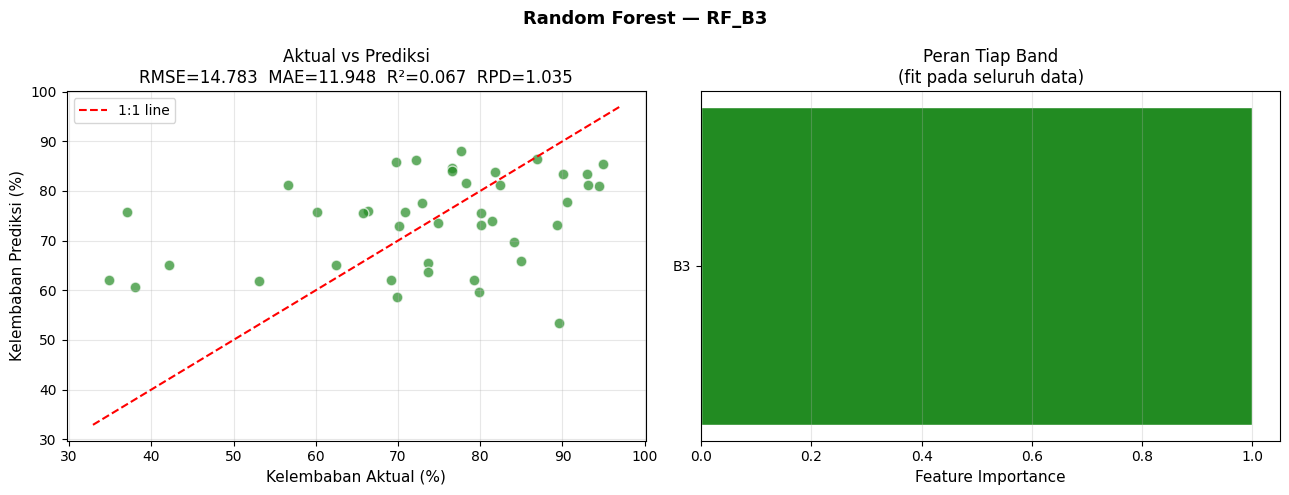

Output disimpan ke: /content/drive/MyDrive/Skripsi/Hasil Pemodelan Baru/RF_B2B3/


In [9]:
result_B2B3 = train_rf(X_B2B3, Y_raw, 'RF_B2B3', ['B2', 'B3'], OUT_DIR, df_merged)
result_B2   = train_rf(X_B2,   Y_raw, 'RF_B2',   ['B2'],        OUT_DIR, df_merged)
result_B3   = train_rf(X_B3,   Y_raw, 'RF_B3',   ['B3'],        OUT_DIR, df_merged)

## 8. Ringkasan perbandingan

In [10]:
print("\n" + "=" * 60)
print("RINGKASAN PERBANDINGAN RF — B2B3 vs B2 vs B3")
print("=" * 60)
print(f"{'Model':<12} {'Band':<10} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'RPD':>8}")
print("-" * 60)
for r in [result_B2B3, result_B2, result_B3]:
    print(f"{r['label']:<12} {r['bands']:<10} {r['rmse']:>8.4f} "
          f"{r['mae']:>8.4f} {r['r2']:>8.4f} {r['rpd']:>8.4f}")

print("\nInterpretasi RPD:")
print("  RPD < 1.5   → model tidak layak untuk prediksi")
print("  RPD 1.5-2.0 → estimasi kasar, terbatas")
print("  RPD > 2.0   → model reliable untuk prediksi")

df_summary = pd.DataFrame([result_B2B3, result_B2, result_B3])
df_summary.to_csv(OUT_DIR + 'ringkasan_rf.csv', index=False)

print("\nScript RF selesai.")


RINGKASAN PERBANDINGAN RF — B2B3 vs B2 vs B3
Model        Band           RMSE      MAE       R²      RPD
------------------------------------------------------------
RF_B2B3      ['B2', 'B3']  14.7840  11.7176   0.0670   1.0353
RF_B2        ['B2']      14.6512  11.7538   0.0837   1.0447
RF_B3        ['B3']      14.7828  11.9476   0.0672   1.0354

Interpretasi RPD:
  RPD < 1.5   → model tidak layak untuk prediksi
  RPD 1.5-2.0 → estimasi kasar, terbatas
  RPD > 2.0   → model reliable untuk prediksi

Script RF selesai.
